# Fase 3 – Componente práctico: Práctica simulada

## Ejercicio 1. Ajuste base y métricas con matriz de confusión para modelos L1 y L2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
path = "Appendix 1 - Database.csv"

df = pd.read_csv(path, encoding="latin1")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df_clean = df.dropna(subset=["InvoiceNo", "Quantity", "UnitPrice"]).copy()

df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

invoice_df = (
    df_clean.groupby("InvoiceNo", as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "max"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        InvoiceTotal=("TotalPrice", "sum")
    )
)

q1 = invoice_df["InvoiceTotal"].quantile(0.25)
q3 = invoice_df["InvoiceTotal"].quantile(0.75)
iqr = q3 - q1

lower = max(0, q1 - 1.5 * iqr)
upper = q3 + 1.5 * iqr

invoice_no_out = invoice_df[
    (invoice_df["InvoiceTotal"] >= lower) &
    (invoice_df["InvoiceTotal"] <= upper)
].dropna(subset=["CustomerID"]).copy()

analysis_date = invoice_no_out["InvoiceDate"].max()

customer_level = (
    invoice_no_out.groupby("CustomerID", as_index=False)
    .agg(
        LastPurchaseDate=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        TotalSpent=("InvoiceTotal", "sum"),
        Country=("Country", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        MinPurchase=("InvoiceTotal", "min"),
        AvgPurchase=("InvoiceTotal", "mean")
    )
)

customer_level["Recency"] = (analysis_date - customer_level["LastPurchaseDate"]).dt.days

customer_level = customer_level[
    ["CustomerID", "LastPurchaseDate", "Recency", "Frequency", "TotalSpent", "Country", "MinPurchase", "AvgPurchase"]
]

customer_level.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,TotalSpent,Country,MinPurchase,AvgPurchase
0,"12,347.0000",2011-12-07 15:52:00,1,6,"3,015.6800",Iceland,224.8200,502.6133
1,"12,348.0000",2011-09-25 13:13:00,74,4,"1,797.2400",Finland,227.4400,449.3100
2,"12,350.0000",2011-02-02 16:01:00,309,1,334.4000,Norway,334.4000,334.4000
3,"12,352.0000",2011-11-03 14:37:00,35,8,"2,506.0400",Norway,120.3300,313.2550
4,"12,353.0000",2011-05-19 17:47:00,203,1,89.0000,Bahrain,89.0000,89.0000


## Definición de la variable objetivo

La variable objetivo se define a partir de la recencia del cliente, se considera que un cliente presenta churn cuando han transcurrido más de 90 días desde su última compra.

- Churn = 1: cliente con riesgo de abandono o sin compras recientes.
- Churn = 0: cliente con actividad reciente.

Dado que la variable Churn se construye directamente desde Recency, esta variable no se incluye como predictora en los modelos, con el fin de evitar una relación circular entre la variable objetivo y las variables explicativas.

In [4]:
model_data = customer_level[[
    "Recency",
    "Frequency",
    "TotalSpent",
    "MinPurchase",
    "AvgPurchase",
    "Country"
]].copy()

model_data["Churn"] = (model_data["Recency"] > 90).astype(int)

model_data["Churn"].value_counts()

Churn
0    2791
1    1454
Name: count, dtype: int64

In [5]:
model_data_encoded = pd.get_dummies(
    model_data,
    columns=["Country"],
    drop_first=True
)

X = model_data_encoded.drop(columns=["Churn", "Recency"])
y = model_data_encoded["Churn"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts())
print("\nDistribución porcentual:")
print(y.value_counts(normalize=True))

Dimensión de X: (4245, 38)
Dimensión de y: (4245,)

Distribución de la variable objetivo:
Churn
0    2791
1    1454
Name: count, dtype: int64

Distribución porcentual:
Churn
0   0.6575
1   0.3425
Name: proportion, dtype: float64


## División de datos y escalamiento

Se utiliza una partición 80/20, donde el 80% de los datos se destina al entrenamiento de los modelos y el 20% restante se reserva como conjunto de prueba; la división se realiza de manera estratificada para conservar la proporción de clientes con churn y sin churn en ambos subconjuntos.

Posteriormente, se aplica estandarización a las variables predictoras. El escalador se ajusta únicamente con los datos de entrenamiento y luego se aplica al conjunto de prueba, lo cual evita fuga de información desde los datos de evaluación hacia el proceso de entrenamiento.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True))

X_train: (3396, 38)
X_test: (849, 38)
y_train: (3396,)
y_test: (849,)

Distribución de clases en entrenamiento:
Churn
0   0.6575
1   0.3425
Name: proportion, dtype: float64

Distribución de clases en prueba:
Churn
0   0.6572
1   0.3428
Name: proportion, dtype: float64


### Entrenamiento de modelos base L1 y L2

In [7]:
model_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=1000,
    random_state=42
)

model_l2 = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=1.0,
    max_iter=1000,
    random_state=42
)

model_l1.fit(X_train_scaled, y_train)
model_l2.fit(X_train_scaled, y_train)

y_pred_l1 = model_l1.predict(X_test_scaled)
y_pred_l2 = model_l2.predict(X_test_scaled)

## Función para calcular métricas desde la matriz de confusión

In [9]:
def calcular_metricas(y_true, y_pred, nombre_modelo):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    
    return {
        "Modelo": nombre_modelo,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Sensitivity_Recall": sensitivity,
        "Specificity": specificity,
        "F1_score": f1
    }

metricas_l1 = calcular_metricas(y_test, y_pred_l1, "Regresión Logística Lasso (L1)")
metricas_l2 = calcular_metricas(y_test, y_pred_l2, "Regresión Logística Ridge (L2)")

metricas_baseline = pd.DataFrame([metricas_l1, metricas_l2])

metricas_baseline

,Modelo,TN,FP,FN,TP,Accuracy,Sensitivity_Recall,Specificity,F1_score
0,Regresión Logística Lasso (L1),451,107,151,140,0.6961,0.4811,0.8082,0.5204
1,Regresión Logística Ridge (L2),449,109,148,143,0.6973,0.4914,0.8047,0.5267


## Matrices de confusión

In [10]:
cm_l1 = confusion_matrix(y_test, y_pred_l1, labels=[0, 1])
cm_l2 = confusion_matrix(y_test, y_pred_l2, labels=[0, 1])

print("Matriz de confusión - Lasso (L1)")
print(cm_l1)

print("\nMatriz de confusión - Ridge (L2)")
print(cm_l2)

Matriz de confusión - Lasso (L1)
[[451 107]
 [151 140]]

Matriz de confusión - Ridge (L2)
[[449 109]
 [148 143]]


## Gráfica de matrices de confusión

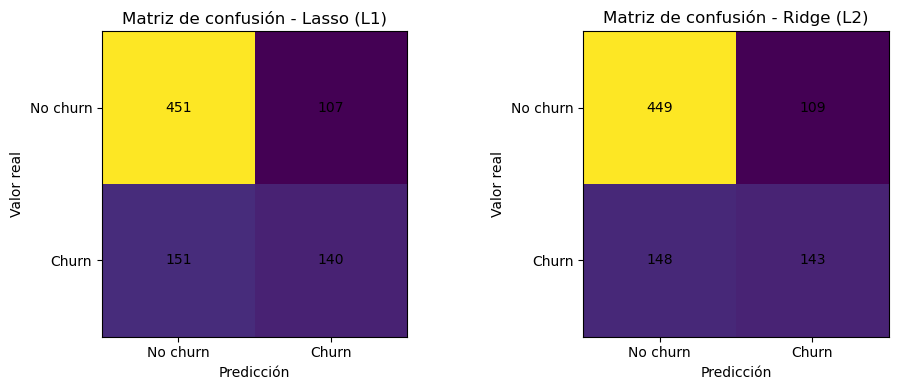

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

matrices = [cm_l1, cm_l2]
titulos = ["Lasso (L1)", "Ridge (L2)"]

for ax, cm, titulo in zip(axes, matrices, titulos):
    im = ax.imshow(cm)
    ax.set_title(f"Matriz de confusión - {titulo}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No churn", "Churn"])
    ax.set_yticklabels(["No churn", "Churn"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Comparación visual de métricas

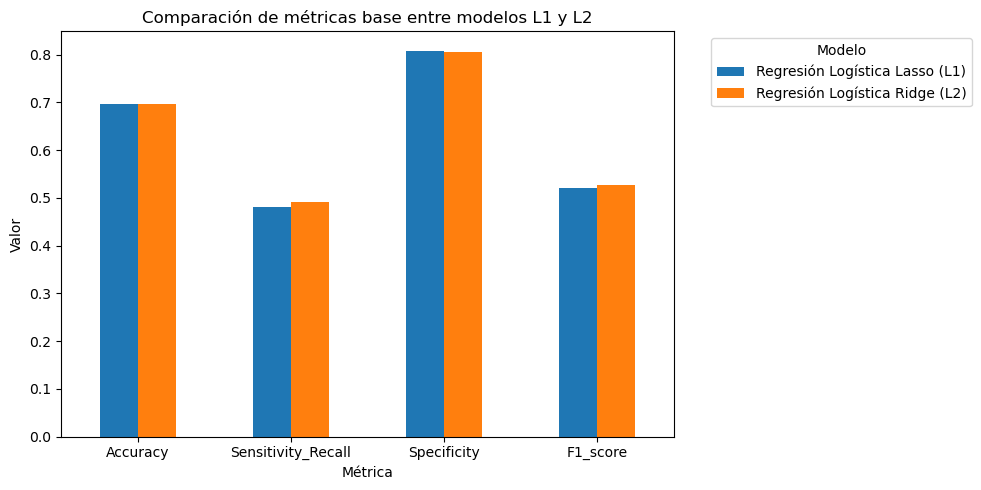

In [12]:
metricas_plot = metricas_baseline.set_index("Modelo")[
    ["Accuracy", "Sensitivity_Recall", "Specificity", "F1_score"]
]

metricas_plot.T.plot(kind="bar", figsize=(10, 5))

plt.title("Comparación de métricas base entre modelos L1 y L2")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Interpretacion
A partir de los resultados obtenidos, los modelos de regresión logística regularizada Lasso (L1) y Ridge (L2) presentan un comportamiento base comparable, ya que ambos utilizan la misma división de datos, las mismas variables predictoras y el mismo procedimiento de escalamiento, la evaluación mediante matriz de confusión permite observar no solo los aciertos globales del modelo, sino también los errores asociados a falsos positivos y falsos negativos.

En este primer ajuste, el análisis no debe centrarse únicamente en el Accuracy, debido a que esta métrica puede ser insuficiente cuando existe diferencia entre la cantidad de clientes con churn y sin churn. Por esta razón, también se analizan la sensibilidad, la especificidad y el F1-score. La sensibilidad permite evaluar la capacidad del modelo para identificar correctamente a los clientes con churn, mientras que la especificidad permite medir qué tan bien reconoce a los clientes que no presentan churn.

Si los valores de sensibilidad y F1-score no son suficientemente altos, esto puede indicar la necesidad de realizar ajustes posteriores en el umbral de decisión o en los hiperparámetros del modelo. Esta primera evaluación funciona como una línea base para comparar los resultados que se obtendrán en los siguientes ejercicios mediante validación cruzada y optimización de hiperparámetros.

## Ejercicio 2. Validación cruzada estratificada de 10 pliegues

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

### Protocolo de validación cruzada

Se utiliza `StratifiedKFold` con 10 pliegues, activando `shuffle=True` y fijando `random_state=42` para garantizar reproducibilidad. La estratificación permite conservar la proporción de clientes con churn y sin churn en cada pliegue.

Para evitar fuga de información, el proceso de estandarización se incluye dentro de un `Pipeline, de esta manera, en cada pliegue el escalador se ajusta únicamente con la porción de entrenamiento correspondiente y luego se aplica a la porción de validación.

In [15]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pipeline_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

pipeline_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

## Función para calcular métricas por pliegue

In [18]:
def evaluar_modelo_cv(modelo, X, y, cv, nombre_modelo):
    resultados = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        modelo.fit(X_tr, y_tr)
        y_pred = modelo.predict(X_val)
        
        cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        accuracy = accuracy_score(y_val, y_pred)
        sensitivity = recall_score(y_val, y_pred)
        specificity = tn / (tn + fp)
        f1 = f1_score(y_val, y_pred)
        
        resultados.append({
            "Modelo": nombre_modelo,
            "Fold": fold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Accuracy": accuracy,
            "Sensitivity_Recall": sensitivity,
            "Specificity": specificity,
            "F1_score": f1
        })
    
    return pd.DataFrame(resultados)

## Ejecutar validación cruzada para L1 y L2

In [19]:
cv_l1 = evaluar_modelo_cv(
    pipeline_l1,
    X_train,
    y_train,
    cv,
    "Regresión Logística Lasso (L1)"
)

cv_l2 = evaluar_modelo_cv(
    pipeline_l2,
    X_train,
    y_train,
    cv,
    "Regresión Logística Ridge (L2)"
)

resultados_cv = pd.concat([cv_l1, cv_l2], ignore_index=True)

resultados_cv

,Modelo,Fold,TN,FP,FN,TP,Accuracy,Sensitivity_Recall,Specificity,F1_score
0,Regresión Logística Lasso (L1),1,189,34,58,59,0.7294,0.5043,0.8475,0.5619
1,Regresión Logística Lasso (L1),2,179,44,59,58,0.6971,0.4957,0.8027,0.5297
2,Regresión Logística Lasso (L1),3,159,64,53,64,0.6559,0.5470,0.7130,0.5224
3,Regresión Logística Lasso (L1),4,181,43,56,60,0.7088,0.5172,0.8080,0.5479
4,Regresión Logística Lasso (L1),5,179,45,49,67,0.7235,0.5776,0.7991,0.5877
5,Regresión Logística Lasso (L1),6,182,42,57,59,0.7088,0.5086,0.8125,0.5438
6,Regresión Logística Lasso (L1),7,184,39,47,69,0.7463,0.5948,0.8251,0.6161
7,Regresión Logística Lasso (L1),8,185,38,62,54,0.7050,0.4655,0.8296,0.5192
8,Regresión Logística Lasso (L1),9,180,43,62,54,0.6903,0.4655,0.8072,0.5070
9,Regresión Logística Lasso (L1),10,178,45,64,52,0.6785,0.4483,0.7982,0.4883


### Resumen de métricas por modelo

Después de calcular las métricas en cada pliegue, se obtiene un resumen por modelo mediante la media y la desviación estándar, la media permite identificar el rendimiento promedio del modelo, mientras que la desviación estándar permite observar qué tan estable fue su comportamiento entre los diferentes pliegues.

In [20]:
metricas_cv = ["Accuracy", "Sensitivity_Recall", "Specificity", "F1_score"]

resumen_cv = (
    resultados_cv
    .groupby("Modelo")[metricas_cv]
    .agg(["mean", "std"])
)

resumen_cv

Accuracy        Sensitivity_Recall        Specificity        F1_score       
                                   mean    std               mean    std        mean    std     mean    std
Modelo                                                                                                     
Regresión Logística Lasso (L1)   0.7044 0.0260             0.5125 0.0485      0.8043 0.0356   0.5424 0.0383
Regresión Logística Ridge (L2)   0.7041 0.0283             0.5176 0.0508      0.8012 0.0359   0.5447 0.0420

## Comparación visual de métricas promedi

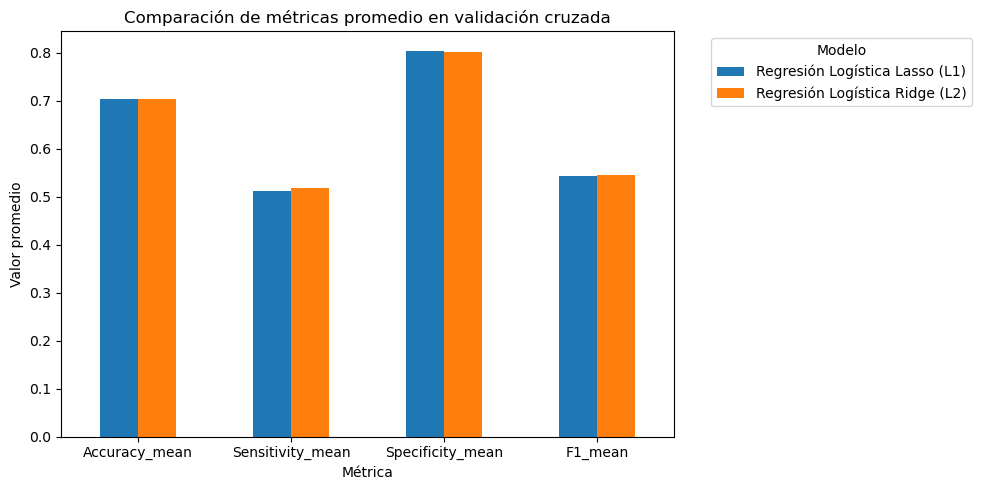

In [22]:
metricas_promedio = resumen_cv_limpio.set_index("Modelo")[
    ["Accuracy_mean", "Sensitivity_mean", "Specificity_mean", "F1_mean"]
]

metricas_promedio.T.plot(kind="bar", figsize=(10, 5))

plt.title("Comparación de métricas promedio en validación cruzada")
plt.xlabel("Métrica")
plt.ylabel("Valor promedio")
plt.xticks(rotation=0)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Gráfico de variabilidad por pliegue

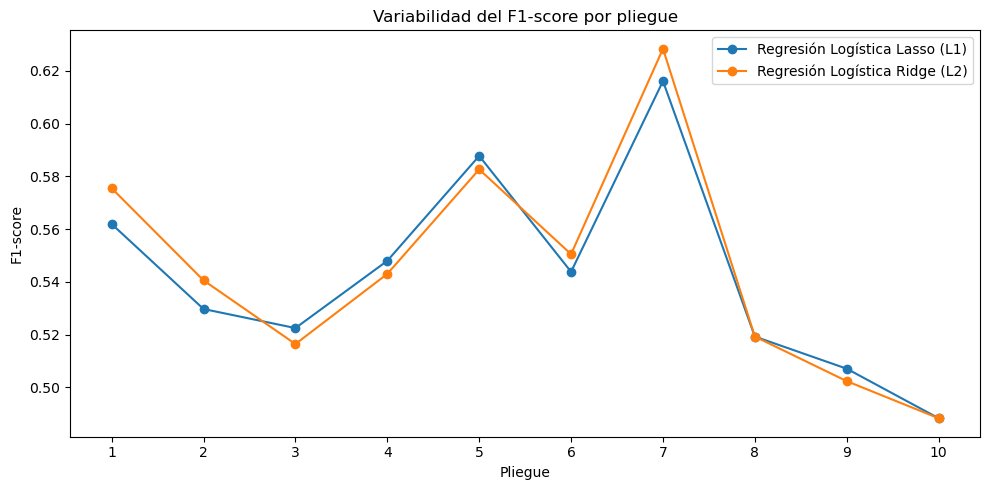

In [23]:
plt.figure(figsize=(10, 5))

for modelo in resultados_cv["Modelo"].unique():
    datos_modelo = resultados_cv[resultados_cv["Modelo"] == modelo]
    plt.plot(
        datos_modelo["Fold"],
        datos_modelo["F1_score"],
        marker="o",
        label=modelo
    )

plt.title("Variabilidad del F1-score por pliegue")
plt.xlabel("Pliegue")
plt.ylabel("F1-score")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

###  Interpretacion de la validación cruzada

La validación cruzada estratificada de 10 pliegues permite evaluar el comportamiento de los modelos Lasso (L1) y Ridge (L2) de una forma más robusta que una única partición de entrenamiento y prueba. Al conservar la proporción de clases en cada pliegue, se reduce el riesgo de que alguna partición tenga una distribución poco representativa de clientes con churn y sin churn.

El análisis de la media de las métricas permite identificar el rendimiento promedio de cada modelo, mientras que la desviación estándar permite evaluar su estabilidad. Una desviación estándar baja indica que el modelo mantiene un comportamiento relativamente consistente entre los diferentes pliegues, mientras que una desviación más alta puede sugerir mayor sensibilidad a la partición de los datos.

En esta etapa todavía no se utiliza el conjunto de prueba, ya que este debe reservarse para la evaluación final. Por tanto, los resultados obtenidos en la validación cruzada sirven como insumo para comparar la estabilidad de los modelos base y preparar la fase posterior de optimización de hiperparámetros.

## Ejercicio 3. Optimización de hiperparámetros para Regresión Logística Lasso (L1)

In [24]:
from sklearn.model_selection import GridSearchCV

### Definición de la grilla de búsqueda para Lasso L1

Para el modelo Lasso L1 se utiliza el solver `liblinear`, debido a que es compatible con la penalización L1 en problemas de clasificación binaria, la grilla de búsqueda se centra en el parámetro `C`, el cual controla la intensidad de la regularización.

Se evalúan diferentes valores de `C` para analizar cómo cambia el desempeño del modelo cuando la penalización es más fuerte o más flexible.

In [26]:
pipeline_l1_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

param_grid_l1 = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_l1 = GridSearchCV(
    estimator=pipeline_l1_grid,
    param_grid=param_grid_l1,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_l1.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           penalty='l1',
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1, param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True, scoring='f1')

## Mostrar mejores hiperparámetros y mejor F1-score

In [27]:
print("Mejores hiperparámetros para Lasso L1:")
print(grid_l1.best_params_)

print("\nMejor F1-score promedio en validación cruzada:")
print(grid_l1.best_score_)

Mejores hiperparámetros para Lasso L1:
{'model__C': 100}

Mejor F1-score promedio en validación cruzada:
0.5481092276538757


## Resultados completos de la búsqueda

resultados_grid_l1 = pd.DataFrame(grid_l1.cv_results_)

columnas_l1 = [
    "param_model__C",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "rank_test_score"
]

resultados_grid_l1 = resultados_grid_l1[columnas_l1].sort_values("rank_test_score")

resultados_grid_l1

## Tabla ordenada por valores de C

In [29]:
resultados_grid_l1_ordenado = pd.DataFrame(grid_l1.cv_results_)[[
    "param_model__C",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score"
]].copy()

resultados_grid_l1_ordenado = resultados_grid_l1_ordenado.sort_values("param_model__C")

resultados_grid_l1_ordenado

,param_model__C,mean_test_score,std_test_score,mean_train_score,std_train_score
0,0.0010,0.0000,0.0000,0.0000,0.0000
1,0.0100,0.0000,0.0000,0.0000,0.0000
2,0.1000,0.5372,0.0432,0.5450,0.0139
3,1.0000,0.5474,0.0478,0.5540,0.0103
4,10.0000,0.5475,0.0446,0.5539,0.0111
5,100.0000,0.5481,0.0453,0.5532,0.0111


## Visualización del F1-score según C

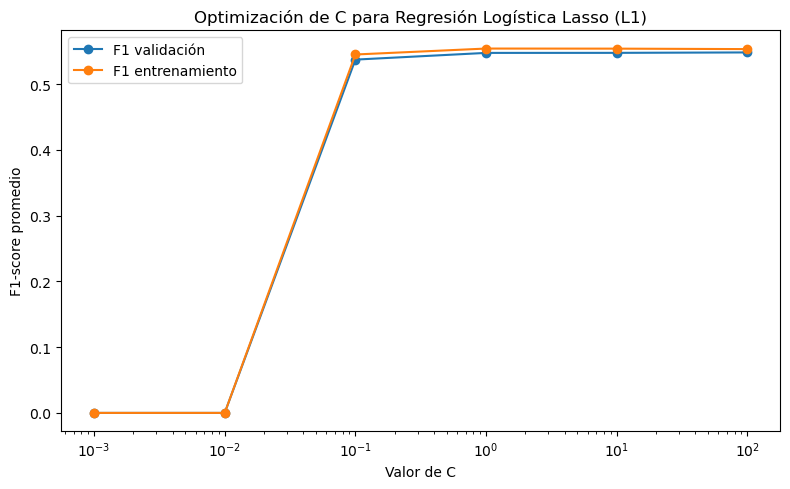

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    resultados_grid_l1_ordenado["param_model__C"].astype(float),
    resultados_grid_l1_ordenado["mean_test_score"],
    marker="o",
    label="F1 validación"
)

plt.plot(
    resultados_grid_l1_ordenado["param_model__C"].astype(float),
    resultados_grid_l1_ordenado["mean_train_score"],
    marker="o",
    label="F1 entrenamiento"
)

plt.xscale("log")
plt.title("Optimización de C para Regresión Logística Lasso (L1)")
plt.xlabel("Valor de C")
plt.ylabel("F1-score promedio")
plt.legend()
plt.tight_layout()
plt.show()

## Número de coeficientes diferentes de cero

In [31]:
mejor_modelo_l1 = grid_l1.best_estimator_

coef_l1 = mejor_modelo_l1.named_steps["model"].coef_[0]

coeficientes_l1 = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente_L1": coef_l1
})

coeficientes_l1["Coeficiente_abs"] = coeficientes_l1["Coeficiente_L1"].abs()

coeficientes_l1["Estado"] = np.where(
    coeficientes_l1["Coeficiente_L1"] == 0,
    "Coeficiente en cero",
    "Coeficiente diferente de cero"
)

resumen_coef_l1 = coeficientes_l1["Estado"].value_counts().reset_index()
resumen_coef_l1.columns = ["Estado", "Cantidad"]

resumen_coef_l1

,Estado,Cantidad
0,Coeficiente diferente de cero,37
1,Coeficiente en cero,1


## Variables más influyentes según Lasso L1

In [33]:
coeficientes_l1_ordenados = (
    coeficientes_l1
    .sort_values("Coeficiente_abs", ascending=False)
    .drop(columns=["Coeficiente_abs"])
)

coeficientes_l1_ordenados.head(15)

,Variable,Coeficiente_L1,Estado
0,Frequency,-3.1881,Coeficiente diferente de cero
20,Country_Italy,-0.4072,Coeficiente diferente de cero
11,Country_Denmark,-0.3744,Coeficiente diferente de cero
3,AvgPurchase,-0.2839,Coeficiente diferente de cero
37,Country_Unspecified,0.2720,Coeficiente diferente de cero
7,Country_Canada,0.2551,Coeficiente diferente de cero
34,Country_USA,-0.2288,Coeficiente diferente de cero
5,Country_Bahrain,0.2013,Coeficiente diferente de cero
36,Country_United Kingdom,-0.1775,Coeficiente diferente de cero
13,Country_European Community,0.1638,Coeficiente diferente de cero


## Gráfico de coeficientes más importantes

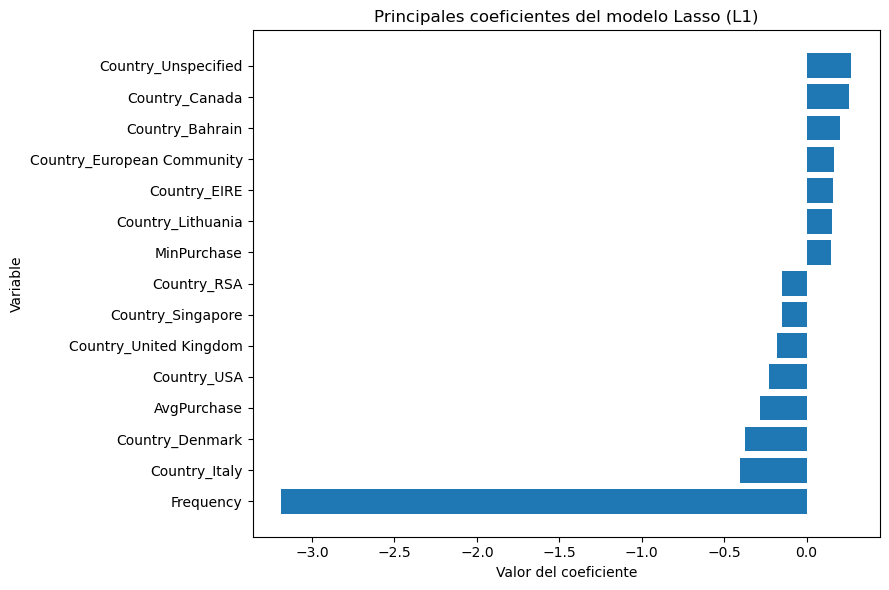

In [34]:
top_coef_l1 = coeficientes_l1_ordenados.head(15).sort_values("Coeficiente_L1")

plt.figure(figsize=(9, 6))

plt.barh(
    top_coef_l1["Variable"],
    top_coef_l1["Coeficiente_L1"]
)

plt.title("Principales coeficientes del modelo Lasso (L1)")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Interpretacion de la optimización Lasso L1

La optimización del modelo Lasso L1 permite evaluar diferentes niveles de regularización mediante el parámetro `C`. Al utilizar F1-score como métrica principal, la búsqueda se orienta a encontrar un equilibrio entre la capacidad del modelo para detectar clientes con churn y la precisión de dicha clasificación.

El modelo Lasso L1 es especialmente útil porque puede reducir algunos coeficientes hasta cero. Esto facilita la interpretación del modelo, ya que permite identificar variables que tienen mayor aporte predictivo y variables que, bajo cierto nivel de regularización, dejan de tener peso dentro del modelo.

Los resultados de esta búsqueda permiten seleccionar la mejor configuración del modelo L1 antes de realizar la evaluación final sobre el conjunto de prueba. Sin embargo, en esta etapa todavía no se utiliza el test set, con el fin de mantener una evaluación final independiente en el Ejercicio 5.

## Ejercicio 4. Optimización de hiperparámetros para Regresión Logística Ridge (L2)

### Definición de la grilla de búsqueda para Ridge L2

Para el modelo Ridge L2 se utiliza el solver `lbfgs`, ya que es compatible con la penalización L2 y es adecuado para problemas de regresión logística, La grilla de búsqueda se centra en el parámetro `C`, que representa la inversa de la fuerza de regularización.

Se evalúan diferentes valores de `C` con el objetivo de identificar qué nivel de regularización permite obtener el mejor equilibrio entre sensibilidad y precisión, medido mediante el F1-score.

In [35]:
pipeline_l2_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

param_grid_l2 = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_l2 = GridSearchCV(
    estimator=pipeline_l2_grid,
    param_grid=param_grid_l2,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_l2.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True, scoring='f1')

## Mostrar mejores hiperparámetros y mejor F1-score

In [36]:
print("Mejores hiperparámetros para Ridge L2:")
print(grid_l2.best_params_)

print("\nMejor F1-score promedio en validación cruzada:")
print(grid_l2.best_score_)

Mejores hiperparámetros para Ridge L2:
{'model__C': 1}

Mejor F1-score promedio en validación cruzada:
0.5504089098844702


## Resultados completos de la búsqueda

In [37]:
resultados_grid_l2 = pd.DataFrame(grid_l2.cv_results_)

columnas_l2 = [
    "param_model__C",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "rank_test_score"
]

resultados_grid_l2 = resultados_grid_l2[columnas_l2].sort_values("rank_test_score")

resultados_grid_l2

,param_model__C,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
3,1.0000,0.5504,0.0454,0.5567,0.0114,1
2,0.1000,0.5483,0.0479,0.5552,0.0143,2
4,10.0000,0.5476,0.0454,0.5542,0.0113,3
5,100.0000,0.5474,0.0457,0.5532,0.0111,4
1,0.0100,0.0648,0.0306,0.0877,0.0183,5
0,0.0010,0.0337,0.0092,0.0481,0.0085,6


## Tabla ordenada por valores de C

In [38]:
resultados_grid_l2_ordenado = pd.DataFrame(grid_l2.cv_results_)[[
    "param_model__C",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score"
]].copy()

resultados_grid_l2_ordenado = resultados_grid_l2_ordenado.sort_values("param_model__C")

resultados_grid_l2_ordenado

,param_model__C,mean_test_score,std_test_score,mean_train_score,std_train_score
0,0.0010,0.0337,0.0092,0.0481,0.0085
1,0.0100,0.0648,0.0306,0.0877,0.0183
2,0.1000,0.5483,0.0479,0.5552,0.0143
3,1.0000,0.5504,0.0454,0.5567,0.0114
4,10.0000,0.5476,0.0454,0.5542,0.0113
5,100.0000,0.5474,0.0457,0.5532,0.0111


## Visualización del F1-score según C

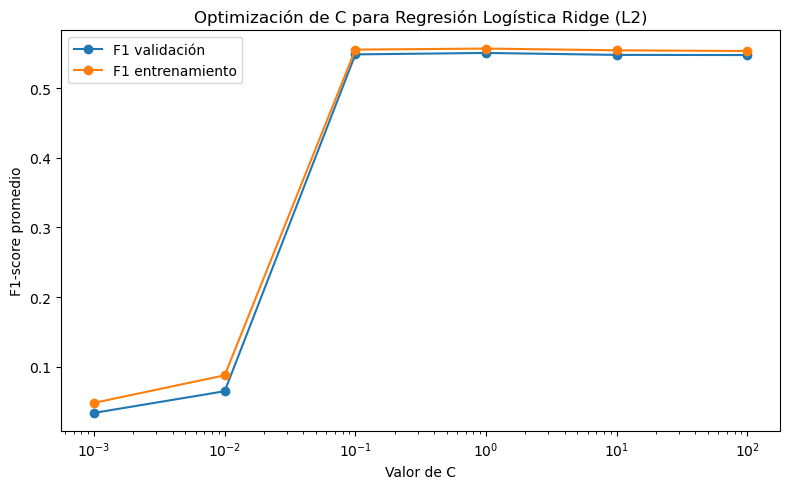

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    resultados_grid_l2_ordenado["param_model__C"].astype(float),
    resultados_grid_l2_ordenado["mean_test_score"],
    marker="o",
    label="F1 validación"
)

plt.plot(
    resultados_grid_l2_ordenado["param_model__C"].astype(float),
    resultados_grid_l2_ordenado["mean_train_score"],
    marker="o",
    label="F1 entrenamiento"
)

plt.xscale("log")
plt.title("Optimización de C para Regresión Logística Ridge (L2)")
plt.xlabel("Valor de C")
plt.ylabel("F1-score promedio")
plt.legend()
plt.tight_layout()
plt.show()

## Coeficientes del mejor modelo Ridge L2

In [40]:
mejor_modelo_l2 = grid_l2.best_estimator_

coef_l2 = mejor_modelo_l2.named_steps["model"].coef_[0]

coeficientes_l2 = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente_L2": coef_l2
})

coeficientes_l2["Coeficiente_abs"] = coeficientes_l2["Coeficiente_L2"].abs()

coeficientes_l2["Estado"] = np.where(
    np.isclose(coeficientes_l2["Coeficiente_L2"], 0),
    "Coeficiente cercano a cero",
    "Coeficiente diferente de cero"
)

resumen_coef_l2 = coeficientes_l2["Estado"].value_counts().reset_index()
resumen_coef_l2.columns = ["Estado", "Cantidad"]

resumen_coef_l2

,Estado,Cantidad
0,Coeficiente diferente de cero,37
1,Coeficiente cercano a cero,1


## Variables más influyentes según Ridge L2

In [41]:
coeficientes_l2_ordenados = (
    coeficientes_l2
    .sort_values("Coeficiente_abs", ascending=False)
    .drop(columns=["Coeficiente_abs"])
)

coeficientes_l2_ordenados.head(15)

,Variable,Coeficiente_L2,Estado
0,Frequency,-2.7519,Coeficiente diferente de cero
20,Country_Italy,-0.2772,Coeficiente diferente de cero
1,TotalSpent,-0.2615,Coeficiente diferente de cero
11,Country_Denmark,-0.2573,Coeficiente diferente de cero
3,AvgPurchase,-0.2364,Coeficiente diferente de cero
37,Country_Unspecified,0.1846,Coeficiente diferente de cero
7,Country_Canada,0.1728,Coeficiente diferente de cero
34,Country_USA,-0.1644,Coeficiente diferente de cero
36,Country_United Kingdom,-0.1618,Coeficiente diferente de cero
2,MinPurchase,0.1508,Coeficiente diferente de cero


## Gráfico de coeficientes principales del modelo Ridge L2

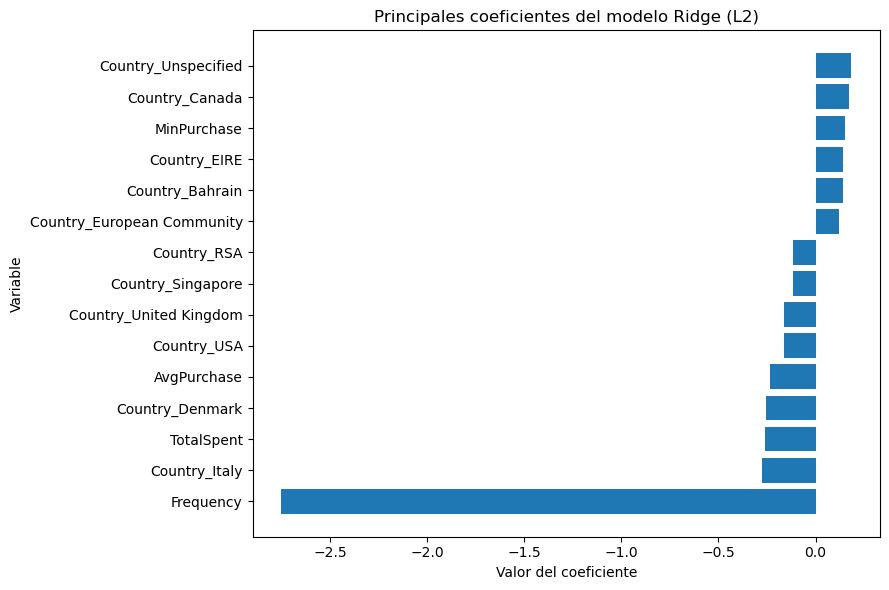

In [42]:
top_coef_l2 = coeficientes_l2_ordenados.head(15).sort_values("Coeficiente_L2")

plt.figure(figsize=(9, 6))

plt.barh(
    top_coef_l2["Variable"],
    top_coef_l2["Coeficiente_L2"]
)

plt.title("Principales coeficientes del modelo Ridge (L2)")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## Comparación inicial entre mejores hiperparámetros L1 y L2

In [43]:
comparacion_grid = pd.DataFrame({
    "Modelo": ["Lasso L1", "Ridge L2"],
    "Mejor_C": [
        grid_l1.best_params_["model__C"],
        grid_l2.best_params_["model__C"]
    ],
    "Mejor_F1_CV": [
        grid_l1.best_score_,
        grid_l2.best_score_
    ]
})

comparacion_grid

,Modelo,Mejor_C,Mejor_F1_CV
0,Lasso L1,100,0.5481
1,Ridge L2,1,0.5504


## Gráfico comparativo del mejor F1-score de L1 y L2

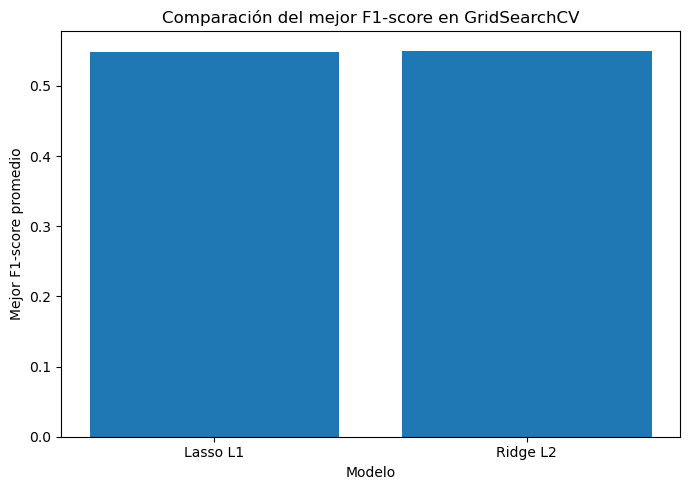

In [44]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparacion_grid["Modelo"],
    comparacion_grid["Mejor_F1_CV"]
)

plt.title("Comparación del mejor F1-score en GridSearchCV")
plt.xlabel("Modelo")
plt.ylabel("Mejor F1-score promedio")
plt.tight_layout()
plt.show()

### Interpretacion inicial de la optimización Ridge L2

La optimización del modelo Ridge L2 permite evaluar diferentes niveles de regularización mediante el parámetro `C`. Al igual que en el modelo Lasso L1, se utiliza el F1-score como métrica principal para mantener coherencia en la comparación entre modelos.

La penalización L2 no elimina variables del modelo, sino que reduce la magnitud de los coeficientes, esto permite conservar toda la información disponible y, al mismo tiempo, controlar la variabilidad de los coeficientes, especialmente cuando existen variables correlacionadas.

Los resultados obtenidos permiten seleccionar la mejor configuración del modelo Ridge L2 antes de realizar la evaluación final sobre el conjunto de prueba. La comparación con el modelo Lasso L1 permite identificar si la reducción suave de coeficientes de Ridge ofrece un mejor desempeño que la selección implícita de variables propia de Lasso.

## Ejercicio 5. Entrenamiento final y evaluación única sobre el conjunto de prueba

### Reentrenamiento de modelos finales

Los modelos finales se entrenan sobre todo el conjunto de entrenamiento utilizando los mejores valores de `C` encontrados previamente:

- Lasso L1: C = 100
- Ridge L2: C = 1

El conjunto de prueba se mantiene separado y se utiliza únicamente para la evaluación final.

In [45]:
modelo_final_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=grid_l1.best_params_["model__C"],
        max_iter=1000,
        random_state=42
    ))
])

modelo_final_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=grid_l2.best_params_["model__C"],
        max_iter=1000,
        random_state=42
    ))
])

modelo_final_l1.fit(X_train, y_train)
modelo_final_l2.fit(X_train, y_train)

print("Modelo final Lasso L1 entrenado con C =", grid_l1.best_params_["model__C"])
print("Modelo final Ridge L2 entrenado con C =", grid_l2.best_params_["model__C"])

Modelo final Lasso L1 entrenado con C = 100
Modelo final Ridge L2 entrenado con C = 1


## Predicción final sobre el conjunto de prueba

In [46]:
y_pred_final_l1 = modelo_final_l1.predict(X_test)
y_pred_final_l2 = modelo_final_l2.predict(X_test)

## Cálculo de métricas finales

In [47]:
metricas_final_l1 = calcular_metricas(
    y_test,
    y_pred_final_l1,
    "Modelo final Lasso (L1)"
)

metricas_final_l2 = calcular_metricas(
    y_test,
    y_pred_final_l2,
    "Modelo final Ridge (L2)"
)

metricas_finales = pd.DataFrame([metricas_final_l1, metricas_final_l2])

metricas_finales

,Modelo,TN,FP,FN,TP,Accuracy,Sensitivity_Recall,Specificity,F1_score
0,Modelo final Lasso (L1),450,108,150,141,0.6961,0.4845,0.8065,0.5222
1,Modelo final Ridge (L2),449,109,148,143,0.6973,0.4914,0.8047,0.5267


## Matrices de confusión finales

In [48]:
cm_final_l1 = confusion_matrix(y_test, y_pred_final_l1, labels=[0, 1])
cm_final_l2 = confusion_matrix(y_test, y_pred_final_l2, labels=[0, 1])

print("Matriz de confusión final - Lasso L1")
print(cm_final_l1)

print("\nMatriz de confusión final - Ridge L2")
print(cm_final_l2)

Matriz de confusión final - Lasso L1
[[450 108]
 [150 141]]

Matriz de confusión final - Ridge L2
[[449 109]
 [148 143]]


## Gráfico de matrices de confusión finales

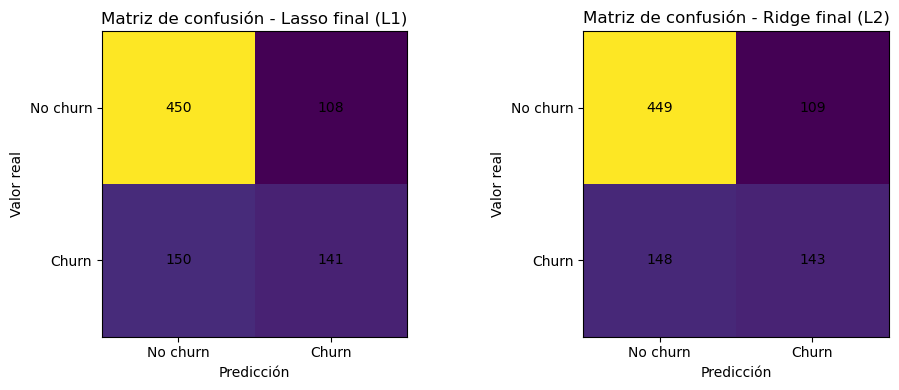

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

matrices_finales = [cm_final_l1, cm_final_l2]
titulos_finales = ["Lasso final (L1)", "Ridge final (L2)"]

for ax, cm, titulo in zip(axes, matrices_finales, titulos_finales):
    im = ax.imshow(cm)
    ax.set_title(f"Matriz de confusión - {titulo}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No churn", "Churn"])
    ax.set_yticklabels(["No churn", "Churn"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Comparación visual de métricas finales

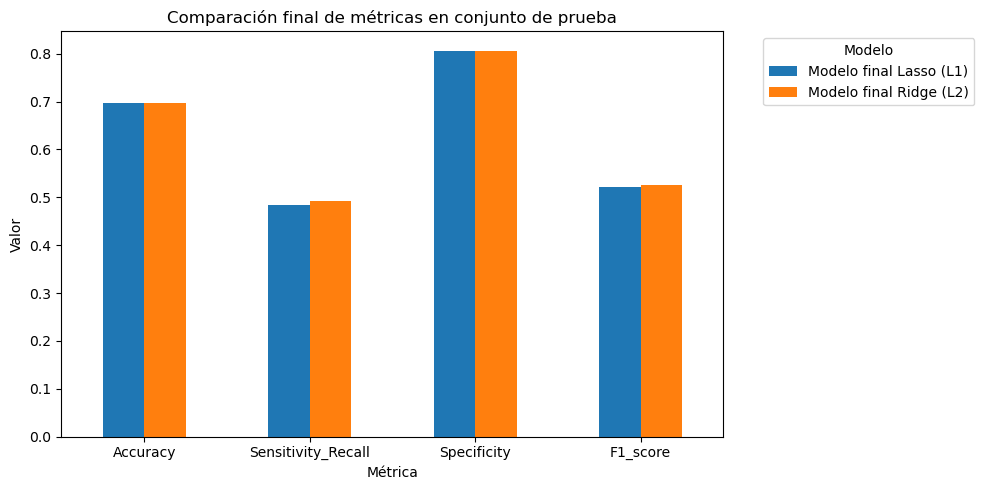

In [50]:
metricas_finales_plot = metricas_finales.set_index("Modelo")[
    ["Accuracy", "Sensitivity_Recall", "Specificity", "F1_score"]
]

metricas_finales_plot.T.plot(kind="bar", figsize=(10, 5))

plt.title("Comparación final de métricas en conjunto de prueba")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Comparación entre validación cruzada y prueba final

In [51]:
comparacion_cv_test = pd.DataFrame({
    "Modelo": ["Lasso L1", "Ridge L2"],
    "Mejor_C": [
        grid_l1.best_params_["model__C"],
        grid_l2.best_params_["model__C"]
    ],
    "F1_CV_GridSearch": [
        grid_l1.best_score_,
        grid_l2.best_score_
    ],
    "F1_Test_Final": [
        metricas_finales.loc[metricas_finales["Modelo"] == "Modelo final Lasso (L1)", "F1_score"].values[0],
        metricas_finales.loc[metricas_finales["Modelo"] == "Modelo final Ridge (L2)", "F1_score"].values[0]
    ],
    "Recall_Test_Final": [
        metricas_finales.loc[metricas_finales["Modelo"] == "Modelo final Lasso (L1)", "Sensitivity_Recall"].values[0],
        metricas_finales.loc[metricas_finales["Modelo"] == "Modelo final Ridge (L2)", "Sensitivity_Recall"].values[0]
    ],
    "Specificity_Test_Final": [
        metricas_finales.loc[metricas_finales["Modelo"] == "Modelo final Lasso (L1)", "Specificity"].values[0],
        metricas_finales.loc[metricas_finales["Modelo"] == "Modelo final Ridge (L2)", "Specificity"].values[0]
    ]
})

comparacion_cv_test

,Modelo,Mejor_C,F1_CV_GridSearch,F1_Test_Final,Recall_Test_Final,Specificity_Test_Final
0,Lasso L1,100,0.5481,0.5222,0.4845,0.8065
1,Ridge L2,1,0.5504,0.5267,0.4914,0.8047


## Comparación visual F1 CV vs F1 Test

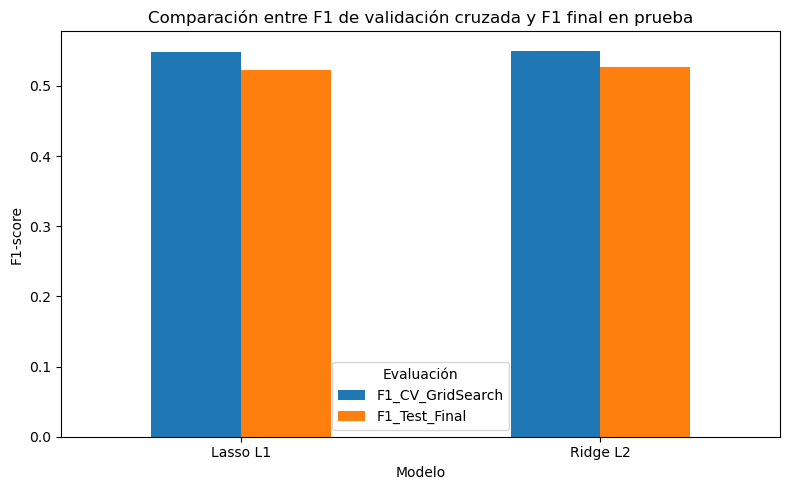

In [52]:
comparacion_cv_test_plot = comparacion_cv_test.set_index("Modelo")[
    ["F1_CV_GridSearch", "F1_Test_Final"]
]

comparacion_cv_test_plot.plot(kind="bar", figsize=(8, 5))

plt.title("Comparación entre F1 de validación cruzada y F1 final en prueba")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.legend(title="Evaluación")
plt.tight_layout()
plt.show()

## Coeficientes finales de L1 y L2

In [54]:
coef_final_l1 = modelo_final_l1.named_steps["model"].coef_[0]
coef_final_l2 = modelo_final_l2.named_steps["model"].coef_[0]

coeficientes_finales = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente_L1": coef_final_l1,
    "Coeficiente_L2": coef_final_l2
})

coeficientes_finales["Abs_L1"] = coeficientes_finales["Coeficiente_L1"].abs()
coeficientes_finales["Abs_L2"] = coeficientes_finales["Coeficiente_L2"].abs()

coeficientes_finales["Estado_L1"] = np.where(
    coeficientes_finales["Coeficiente_L1"] == 0,
    "Cero",
    "Diferente de cero"
)

coeficientes_finales["Estado_L2"] = np.where(
    np.isclose(coeficientes_finales["Coeficiente_L2"], 0),
    "Cercano a cero",
    "Diferente de cero"
)

coeficientes_finales.sort_values("Abs_L1", ascending=False).head(15)

,Variable,Coeficiente_L1,Coeficiente_L2,Abs_L1,Abs_L2,Estado_L1,Estado_L2
0,Frequency,-3.1881,-2.7519,3.1881,2.7519,Diferente de cero,Diferente de cero
20,Country_Italy,-0.4072,-0.2772,0.4072,0.2772,Diferente de cero,Diferente de cero
11,Country_Denmark,-0.3744,-0.2573,0.3744,0.2573,Diferente de cero,Diferente de cero
3,AvgPurchase,-0.2839,-0.2364,0.2839,0.2364,Diferente de cero,Diferente de cero
37,Country_Unspecified,0.2720,0.1846,0.2720,0.1846,Diferente de cero,Diferente de cero
7,Country_Canada,0.2551,0.1728,0.2551,0.1728,Diferente de cero,Diferente de cero
34,Country_USA,-0.2288,-0.1644,0.2288,0.1644,Diferente de cero,Diferente de cero
5,Country_Bahrain,0.2013,0.1399,0.2013,0.1399,Diferente de cero,Diferente de cero
36,Country_United Kingdom,-0.1775,-0.1618,0.1775,0.1618,Diferente de cero,Diferente de cero
13,Country_European Community,0.1638,0.1198,0.1638,0.1198,Diferente de cero,Diferente de cero


## Resumen de esparsidad L1 y L2

In [55]:
resumen_esparsidad = pd.DataFrame({
    "Modelo": ["Lasso L1", "Ridge L2"],
    "Coeficientes_diferentes_de_cero": [
        (coef_final_l1 != 0).sum(),
        (~np.isclose(coef_final_l2, 0)).sum()
    ],
    "Coeficientes_cero_o_cercanos_a_cero": [
        (coef_final_l1 == 0).sum(),
        (np.isclose(coef_final_l2, 0)).sum()
    ],
    "Total_variables": [
        len(coef_final_l1),
        len(coef_final_l2)
    ]
})

resumen_esparsidad

,Modelo,Coeficientes_diferentes_de_cero,Coeficientes_cero_o_cercanos_a_cero,Total_variables
0,Lasso L1,37,1,38
1,Ridge L2,37,1,38


## Comparación gráfica de coeficientes principales L1 vs L2

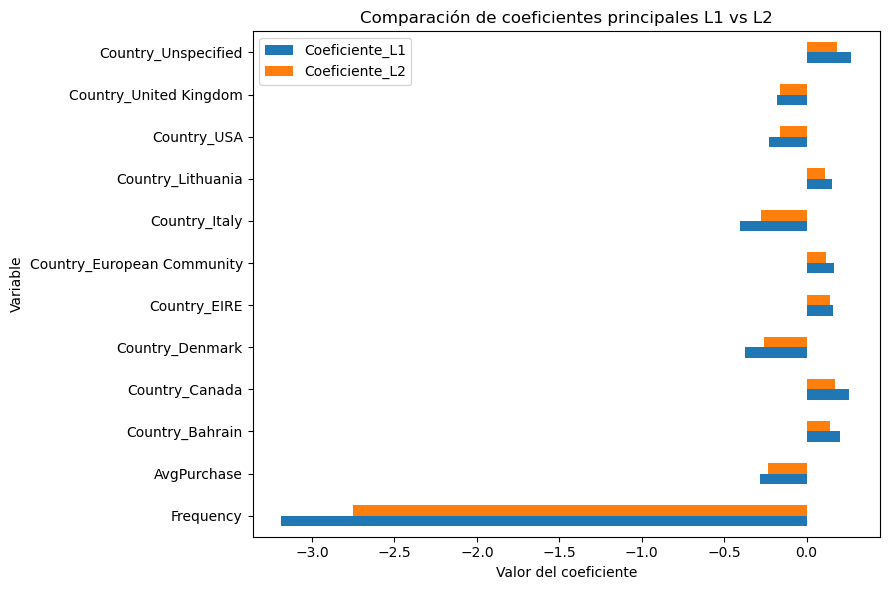

In [56]:
top_variables = (
    coeficientes_finales
    .sort_values("Abs_L1", ascending=False)
    .head(12)["Variable"]
)

coef_plot = coeficientes_finales[
    coeficientes_finales["Variable"].isin(top_variables)
].copy()

coef_plot = coef_plot.set_index("Variable")[["Coeficiente_L1", "Coeficiente_L2"]]

coef_plot.plot(kind="barh", figsize=(9, 6))

plt.title("Comparación de coeficientes principales L1 vs L2")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## Interpretacion final en Markdown para cerrar el notebook

### Reflexión final del entrenamiento y evaluación en prueba

La evaluación final sobre el conjunto de prueba permite comparar el desempeño real de los modelos Lasso L1 y Ridge L2 después de la optimización de hiperparámetros. Este conjunto de prueba no fue utilizado durante la validación cruzada ni durante la búsqueda de hiperparámetros, por lo que representa una evaluación independiente.

La comparación de métricas permite identificar cuál modelo ofrece mejor desempeño en términos de Accuracy, Sensitivity o Recall, Specificity y F1-score. En un problema de churn, la sensibilidad es especialmente importante, ya que permite medir la capacidad del modelo para identificar correctamente a los clientes con riesgo de abandono.
